<a href="https://colab.research.google.com/github/NairMpc/DataScience/blob/main/Assignment_12_RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Load Dataset & Name Columns
We can load the Glass dataset directly from the UCI repository using Python from

### UCI Glass dataset URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/glass/glass.data"

The Glass dataset (UCI) usually has no headers, so we must assign them manually from the given description

which is an excel file: glass.xlsx


In [ ]:
import pandas as pd

In [ ]:
# description = pd.read_excel('/content/glass.xlsx')
# description.values

In [ ]:
#naming columns from above description.
column_names = ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe','Type']

##1. Exploratory Data Analysis (EDA):

First - Load data , naming columns

In [ ]:

# UCI Glass dataset URL
#url = "https://archive.ics.uci.edu/ml/machine-learning-databases/glass/glass.data"
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/glass.csv"

# Load dataset
df = pd.read_csv(url, names=column_names)
df.head()


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


Let us check the columns for unique values as described in the description.

In [ ]:
df['Type'].unique()

array([1, 2, 3, 5, 6, 7])

The unique values to the column matches . And the previous 9 columns also match.

In [ ]:
df.shape

(214, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


The 9 float64 columns (RI, Na, Mg, Al, Si, K, Ca, Ba, Fe) represent continuous numerical data. These are measurements that can take on any value within a range.
The last int64 column (Type) is indeed a numerical categorical variable. Although it's represented by integers 1, 2, 3, 5, 6, 7, these numbers represent distinct categories or types of glass, not quantities that can be added or subtracted in a meaningful way, but only a classification.

It seems there are no null values in any column.

In [ ]:
# display column indices
for i, col in enumerate(df.columns):
    print(f"Index {i}: {col}")


Index 0: RI
Index 1: Na
Index 2: Mg
Index 3: Al
Index 4: Si
Index 5: K
Index 6: Ca
Index 7: Ba
Index 8: Fe
Index 9: Type


### Descriptive Statistics
First, let's look at the descriptive statistics of the numerical columns. This can give us an initial idea about the range, central tendency, and potential spread of the data, which might hint at outliers (e.g., very high max values compared to the mean/median).

In [ ]:
display(df.describe())

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [ ]:
#This code display median of each column
for col in df.columns:
  print(f"Median of '{col}': {df[col].median():.3f}")

Median of 'RI': 1.518
Median of 'Na': 13.300
Median of 'Mg': 3.480
Median of 'Al': 1.360
Median of 'Si': 72.790
Median of 'K': 0.555
Median of 'Ca': 8.600
Median of 'Ba': 0.000
Median of 'Fe': 0.000
Median of 'Type': 2.000


###Let's go through the summary statistics for each column:

RI (Refractive Index): The values range from 1.511 to 1.534. The mean (1.518) is close to the median (1.518), suggesting a relatively symmetrical distribution. The standard deviation is very small (0.003), indicating that most values are clustered closely around the mean.

Na (Sodium): Ranges from 10.73 to 17.38. The mean (13.407) is slightly higher than the median (13.300), which might suggest a slight right skew. There's a reasonable spread (std 0.816).

Mg (Magnesium): The range is from 0.0 to 4.49. The mean (2.684) is considerably lower than the median, and the 25% quartile is 2.11, while the 0.0 min value indicates that some glass types have no Magnesium, making the distribution highly skewed towards higher values for those that contain Mg. This column has a large standard deviation (1.442) relative to its mean, indicating a wide spread.

Al (Aluminum): Values range from 0.29 to 3.50. The mean (1.444) is slightly higher than the median (1.360), indicating a slight right skew. The standard deviation (0.499) shows a moderate spread.

Si (Silicon): Ranges from 69.81 to 75.41. The mean (72.650) and median (72.790) are quite close, suggesting a fairly symmetrical distribution. The standard deviation (0.774) indicates a moderate spread.

K (Potassium): The range is from 0.0 to 6.21. Similar to Magnesium, the min value of 0.0 suggests that some glass types contain no Potassium. The mean (0.497) is lower than the median (0.555), but the 75th percentile is 0.61. The high maximum value (6.21) compared to the 75th percentile suggests potential outliers on the higher end, indicating a highly skewed distribution. The standard deviation (0.652) is significant.

Ca (Calcium): Ranges from 6.99 to 16.19. The mean (8.956) is close to the median (8.600), indicating a relatively symmetrical distribution, though there's a wider range on the higher end (max 16.19). The standard deviation (1.423) shows a decent spread.

Ba (Barium): The range is from 0.0 to 3.15. With a mean (0.175) very close to the minimum/median (0.0) and the 75th percentile also at 0.0, this column is highly skewed with many zero values and a few higher values, indicating the presence of Barium only in specific glass types. The max value of 3.15 is a significant outlier compared to the rest of the data. The standard deviation (0.497) is large relative to its mean.

Fe (Iron): Ranges from 0.0 to 0.51. Similar to Mg, K, and Ba, the mean (0.057) is close to the minimum/median(0.0), and the 75th percentile is also 0.0. This indicates many zero values, suggesting Iron is present only in certain types of glass, or in very small quantities, and that any non-zero values could be considered outliers or specific characteristics of those glass types. The standard deviation (0.097) is also large relative to its mean.

Type: Ranges from 1 to 7. This is a categorical variable, so the statistical measures like mean, std, min, and max are not directly interpretable as continuous values, but they do tell us the range of the class labels.



#2: Data Visualization:

###1. Visualizing Outliers with Box Plots
Box plots are excellent for visually identifying outliers. An outlier is typically defined as a data point that falls outside the 1.5 times the interquartile range (IQR) above the upper quartile or below the lower quartile. We'll plot box plots for all numerical features.

Outliers can represent unusual observations, errors in data collection, or genuine extreme values that differ significantly from the rest of the dataset. Their presence can indicate skewness, heavy tails, or other interesting characteristics of the data distribution.

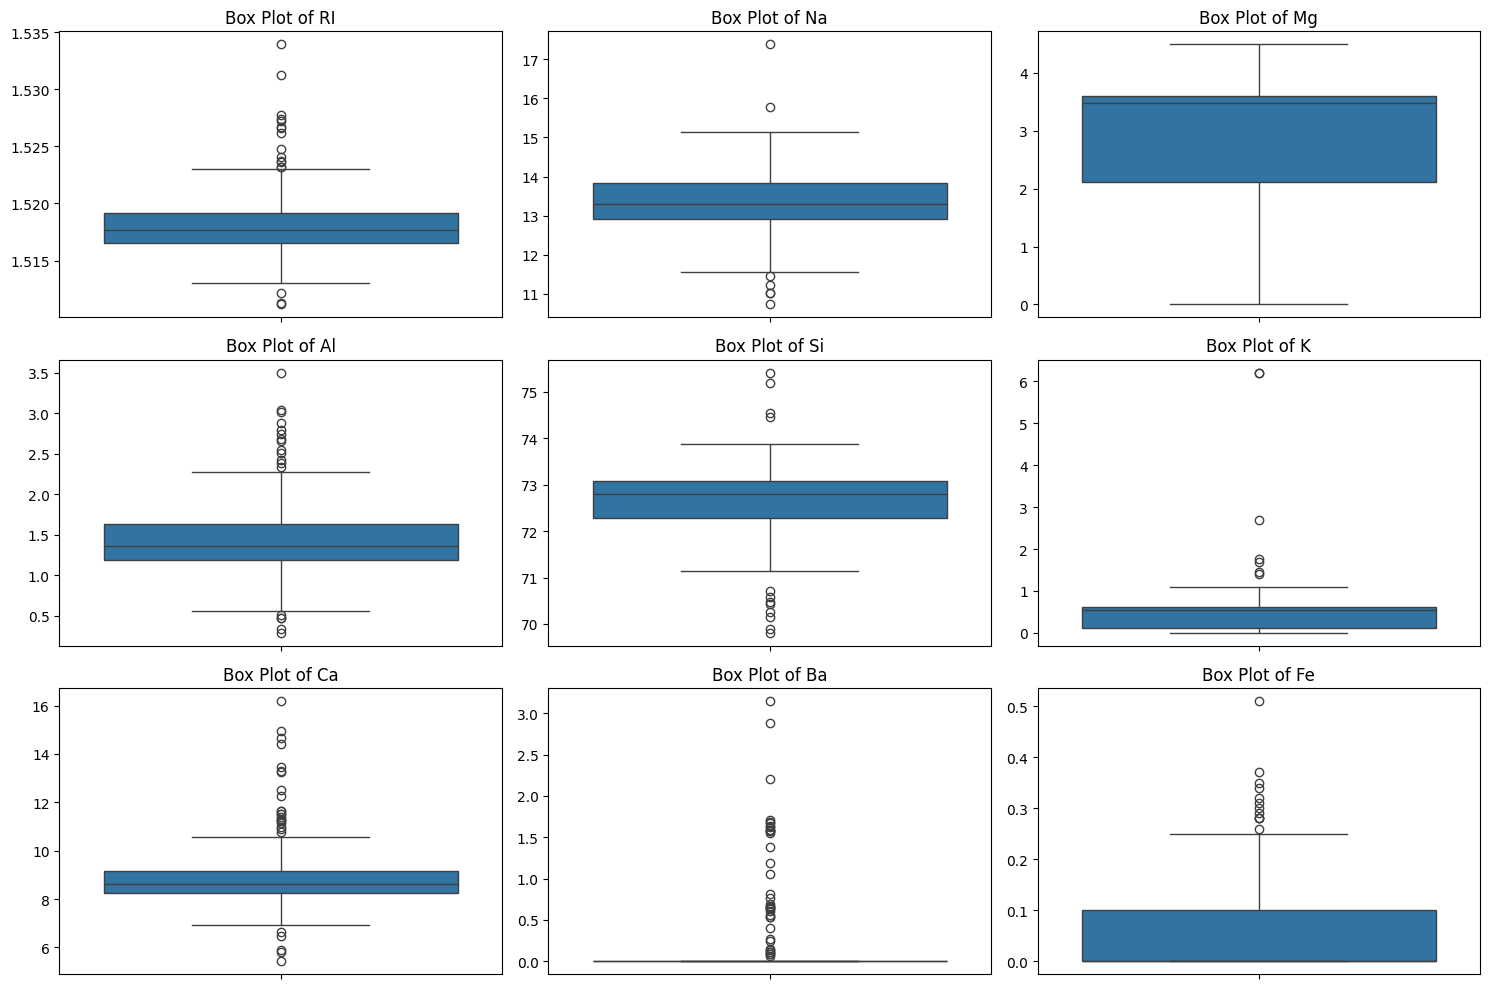

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Exclude 'Type' as it's a categorical target variable, not a continuous feature for outlier detection this way
numerical_cols = df.drop(columns=['Type']).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of numerical columns
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('') # Remove y-axis label to avoid clutter
plt.tight_layout()
plt.show()

###Comment on Box Plots and Outliers:
The box plots for the numerical features indicate the presence of outliers across several variables, despite many features showing relatively tight distributions in their summary statistics. These outliers arise due to the IQR-based definition, where even small deviations are flagged when the data is highly concentrated. In the context of the glass dataset, such values are likely to reflect natural variability among different glass types rather than data errors. Since Random Forest models are robust to outliers and do not rely on strict distributional assumptions, these values will be retained. Further preprocessing (such as transformation or capping) will only be considered if model performance suggests any adverse impact.

###2. Checking Distributions with Histograms
Following the box plot analysis, histograms are used to further examine the distribution of each numerical feature. While box plots highlight the presence of outliers, histograms provide a clearer view of the underlying data distribution, including shape, skewness, and frequency patterns. This step helps in understanding whether the variables follow normal or skewed distributions and in identifying any need for transformations. These insights will support better feature understanding before proceeding with model building.


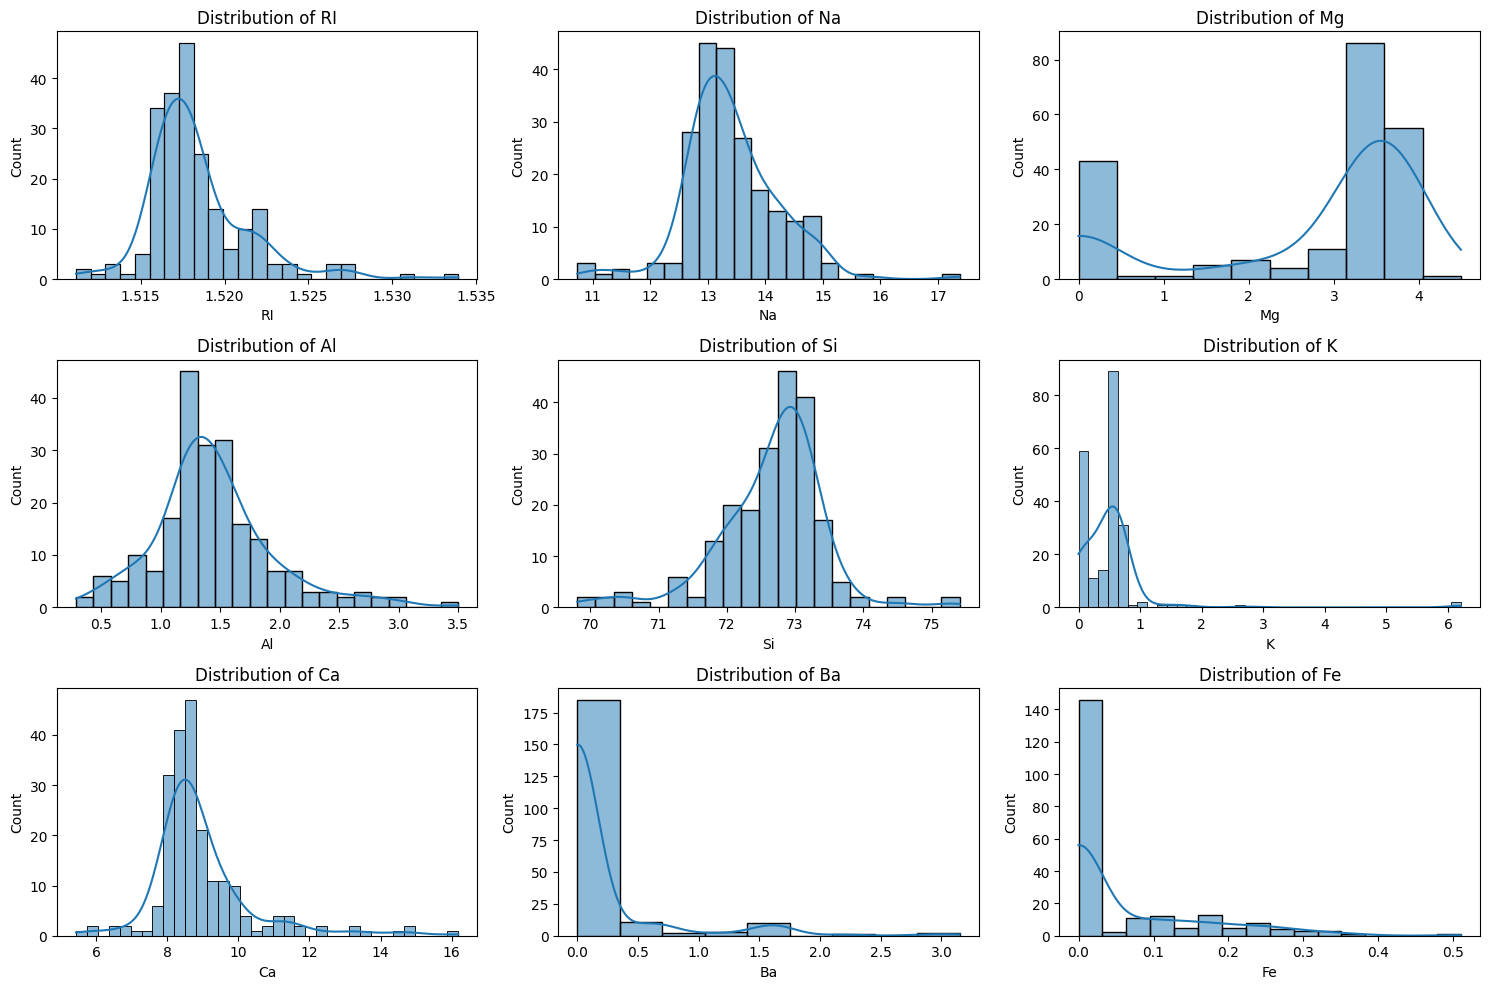

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], kde=True) # kde=True adds a kernel density estimate curve
    plt.title(f'Distribution of {col}')
    #plt.xlabel('') # Remove x-axis label to avoid clutter
plt.tight_layout()
plt.show()

### Interpretation of Histograms and Next Steps:

Relatively Symmetrical/Normal-like Distributions**: Features like `RI`, `Na`,`Al`, `Si`, and `Ca` appear to have distributions that are somewhat bell-shaped, though some might have slight skewness. This indicates a good spread of values around a central tendency.

Right-Skewed Distributions with Zero-Inflation**: `Mg`, `K`, `Ba`, and `Fe` show significant right-skewness, often with a large concentration of values near zero. This confirms the observations from the descriptive statistics where several elements had minimums or 75th percentiles at 0.0, indicating their absence or very low presence in many glass types, and higher values for specific types. This is common in chemical composition datasets where certain elements are not universally present.

###Next Steps:

Given that we are moving towards building a Random Forest model, which is robust to skewed distributions and outliers, direct transformations (like log or square root) are often not strictly necessary for these features. Decision trees work by making splits based on feature values, so the absolute scale or distribution shape is less critical than for linear models. However, understanding these distributions is vital for feature engineering or if other model types are considered later.

After examining the individual distributions of features, the next step is to analyze the relationships between variables and their association with the target variable (Type). This includes visualizing feature-to-target relationships and exploring inter-feature correlations to identify important predictors and potential dependencies among variables.

###relationships between variables and their association with the target variable (Type)
###1.Boxplots (by target class)

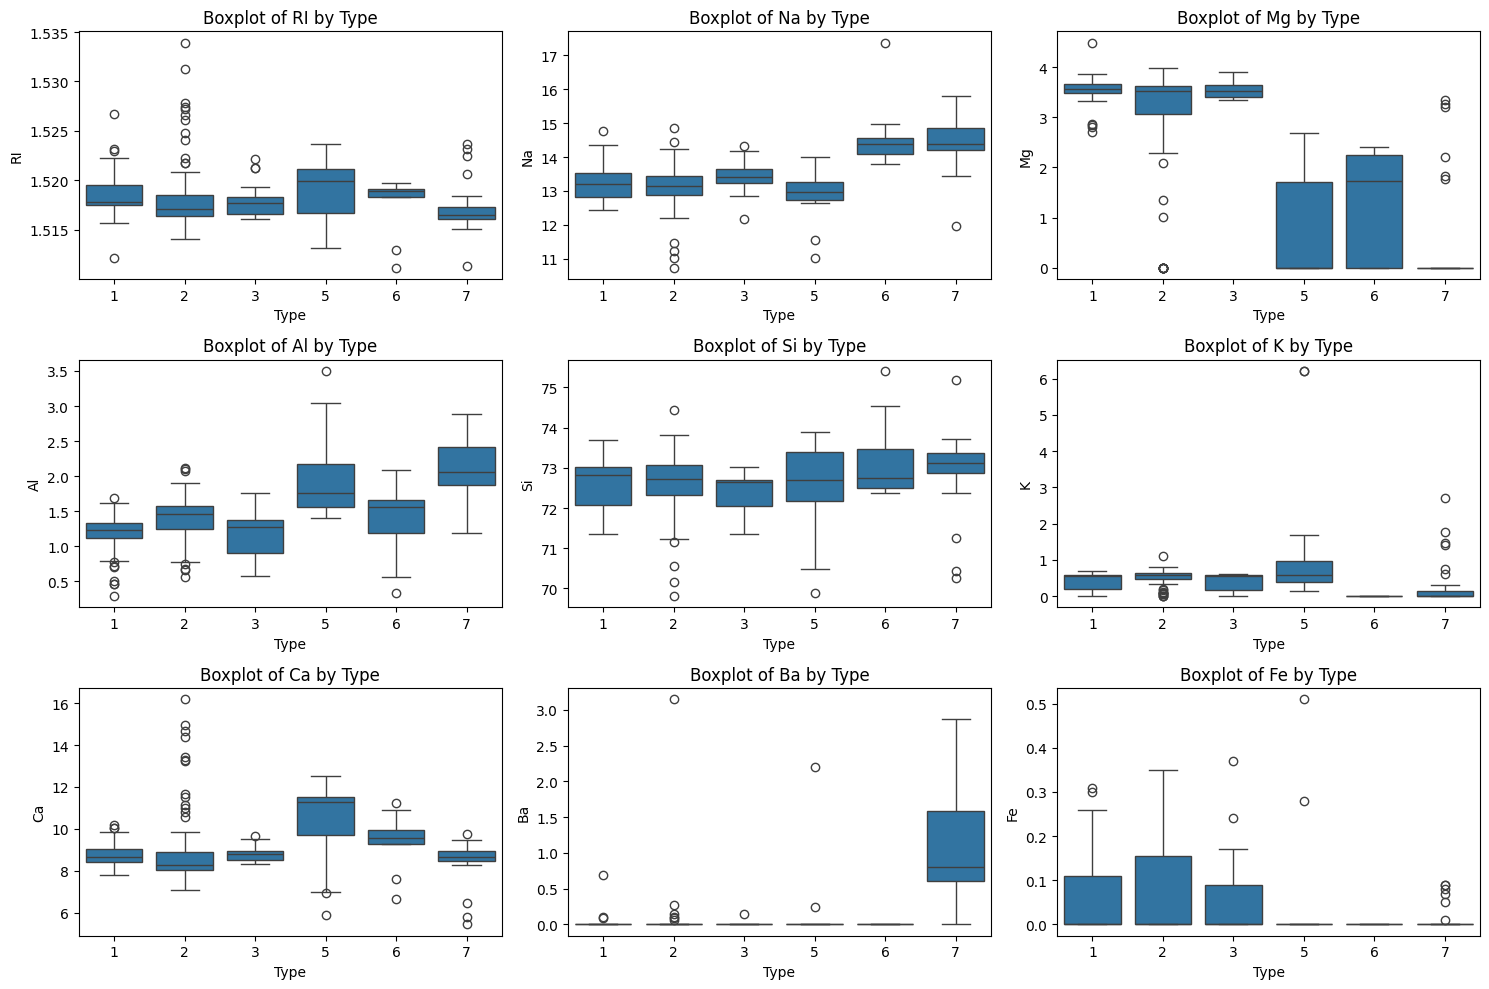

In [ ]:
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3,3,i+1)
    sns.boxplot(x='Type', y=col, data=df)
    plt.title(f"Boxplot of {col} by Type")
    #plt.ylabel('')
plt.tight_layout()
plt.show()


### Interpretation of Box Plots (Features vs. Type)

These box plots visualize the distribution of each numerical feature for each `Type` of glass. This helps in understanding which features are good discriminators between the different glass types.

*   **RI (Refractive Index) vs. Type**: The box plots show clear separation in RI values for different glass types. For example, Type 1 and Type 2 generally have higher RI values compared to Type 5, 6, and 7. This indicates that RI is a strong distinguishing feature among glass types.

*   **Na (Sodium) vs. Type**: Sodium content also shows distinct distributions across glass types. Type 1 and 2 tend to have higher Sodium, while Type 5, 6, and 7 show different ranges. Some overlap exists, but there are noticeable differences in median and spread.

*   **Mg (Magnesium) vs. Type**: Magnesium content appears to be a very strong discriminator. Type 1 and 2 show high Mg content, while Type 5, 6, and 7 have little to no Mg. This suggests Mg is a crucial element for classifying glass types.

*   **Al (Aluminum) vs. Type**: Aluminum content also varies significantly across glass types. Type 2, for instance, shows a higher median Al content than Type 1. Type 5, 6, and 7 also exhibit unique Al ranges, making it another useful feature.

*   **Si (Silicon) vs. Type**: Silicon content generally shows some variation, but the distributions for different glass types might overlap more compared to other features. While there are differences, it might not be as strong a discriminator as Mg or RI.

*   **K (Potassium) vs. Type**: Potassium content is highly variable. Some types (e.g., Type 1, 2) show moderate K levels, while others (Type 5, 6, 7) have either very low or very high K values, indicating it can be a strong, albeit more sporadically present, distinguishing feature.

*   **Ca (Calcium) vs. Type**: Calcium content also displays distinct patterns. Type 1 and 2 have generally lower Ca, while Type 5, 6, and 7 tend to have higher Ca content. This makes Ca a valuable feature for classification.

*   **Ba (Barium) vs. Type**: Barium is a highly distinguishing feature, particularly for Type 7, where it shows significantly higher values compared to other types which often have zero Barium. This makes Ba very important for identifying specific glass compositions.

*   **Fe (Iron) vs. Type**: Iron content, similar to Barium, is often zero for many glass types but can be present in specific types (e.g., Type 5, 6). Its presence or absence can be a key indicator for certain glass classifications.

**Overall Insight**: These box plots clearly demonstrate that most chemical components (RI, Na, Mg, Al, K, Ca, Ba, Fe) exhibit distinct distributions across the different glass types. Features like Magnesium, Barium, and Refractive Index appear to be particularly strong discriminators, showing clear separation between the categories. Silicon, while showing some variation, might have more overlapping distributions. This visual analysis confirms that these chemical properties are highly relevant for classifying glass types, which bodes well for a classification task.

Box plot (feature vs target) → used for feature importance / discrimination

When a feature shows clearly different distributions (separation in medians, ranges, or spread) across categories (glass types), it means:

The feature carries useful information about class identity
A model can use that feature to distinguish between types more easily
There is low ambiguity between classes based on that feature

Applying this to our analysis:

Strong predictive features (clear separation):

Mg (Magnesium) → very strong (almost zero vs high separation)

Ba (Barium) → highly distinctive for certain types (e.g., Type 7)

RI (Refractive Index) → good separation across groups

Moderately predictive (some overlap but still useful):

Na, Al, Ca, K

Weaker predictive feature:

Si (Silicon) → more overlap → less discriminative power


###Next:Relationship between features - Pairplot

Text(0.5, 1.0, 'Correlation Matrix')

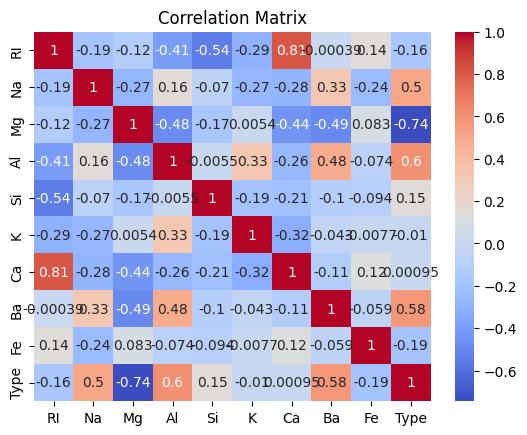

In [ ]:
# Correlation matrix for checking multicollinearity
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')

Looking at the correlation matrix, here are some pairs of features with strong correlations:

RI (Refractive Index) and Ca (Calcium): They have a strong positive correlation of approximately 0.81.

RI (Refractive Index) and Si (Silicon): They show a strong negative correlation of approximately -0.54.

Mg (Magnesium) and Al (Aluminum): They have a moderately strong negative correlation of approximately -0.48.

Ca (Calcium) and Ba (Barium): They also exhibit a moderately strong negative correlation of approximately -0.49.

These correlations indicate that these features tend to change together, either in the same direction (positive) or opposite directions (negative).

While Random Forest models are generally robust to multicollinearity, understanding these correlations is still valuable for interpreting the data and potentially for feature engineering if needed later. For instance, highly correlated features might indicate redundancy, but Random Forests can handle this by selecting one or the other feature during tree construction without much penalty.

To further visualize these relationships and see how they interact with the target variable (Type), the next step in our exploratory data analysis is to create a Pair Plot. This will help us observe:

Feature interactions: How pairs of features relate to each other.
Class separability: How well different glass Types are separated based on combinations of features.

Let's generate the pair plot now:



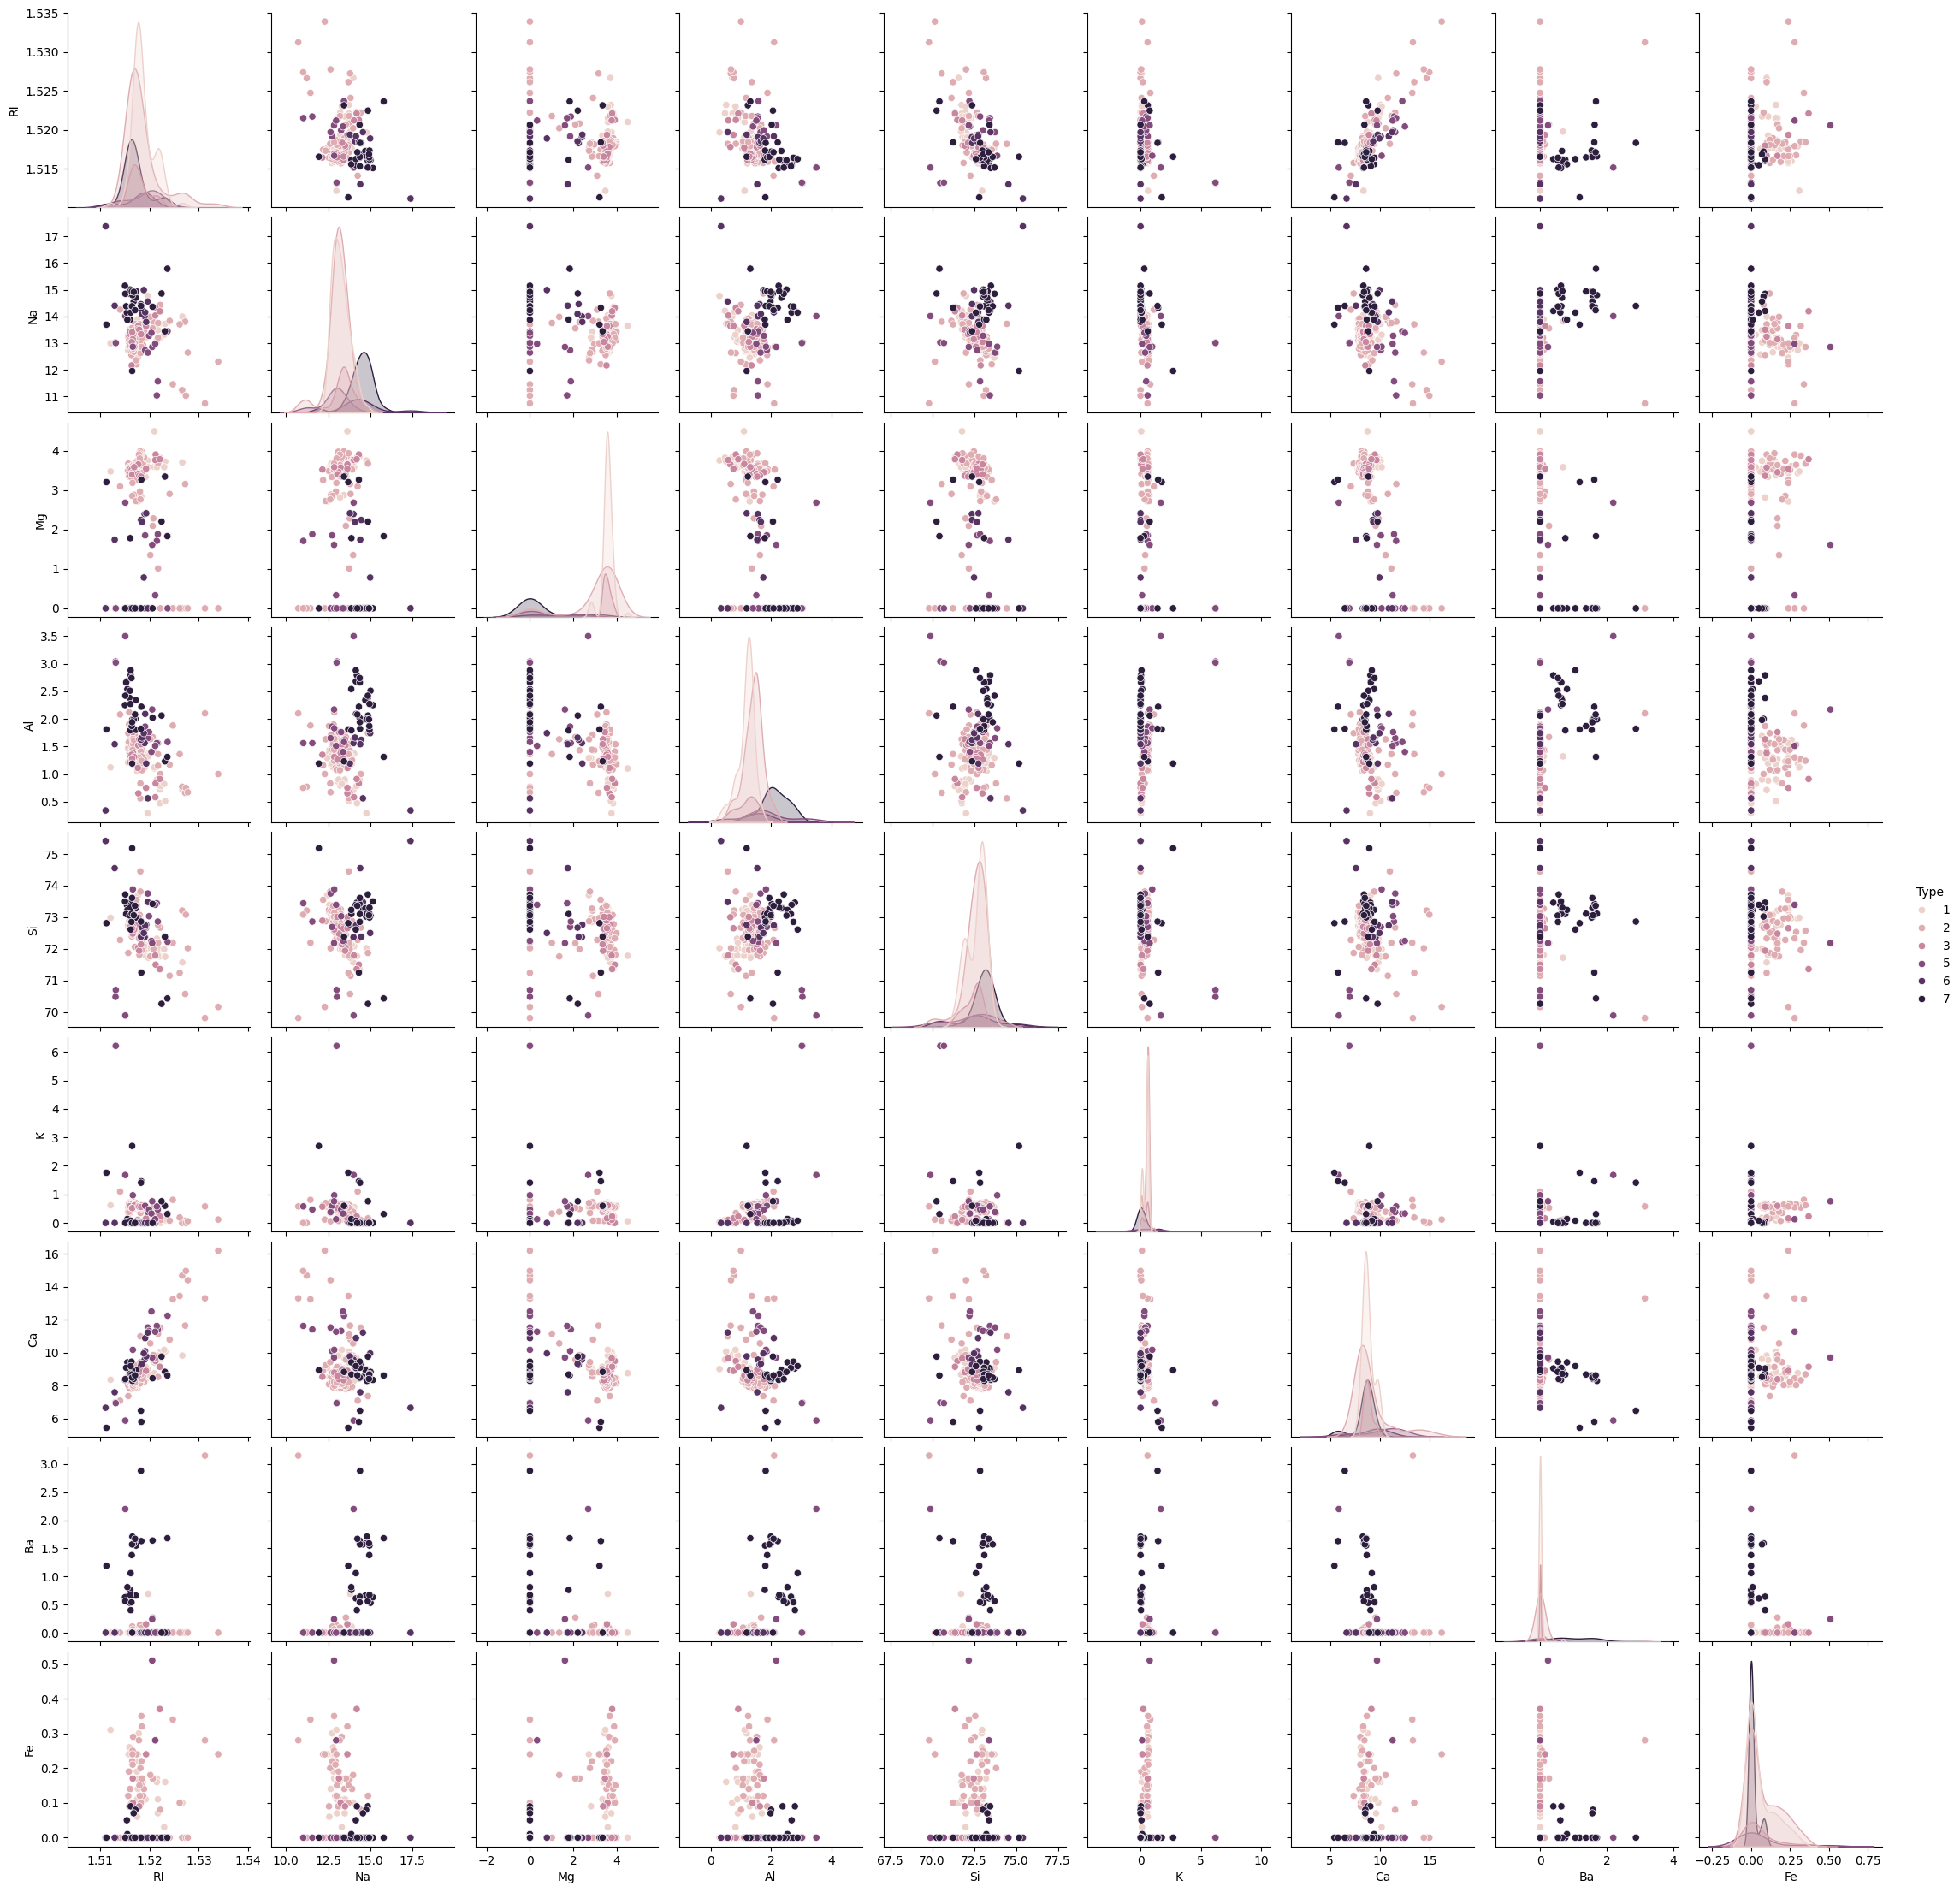

In [ ]:
#Pairplot of features
sns.pairplot(df, hue='Type') # kind='hist' give histogram
plt.show()


The pair plot provides both univariate (diagonal) and bivariate (off-diagonal) insights into the dataset. The diagonal plots show the distribution of individual features, revealing that Mg, RI, Al, Ca, and Na exhibit clear variation across glass types, making them strong predictors. Ba, K, and Fe are also informative, not through perfect separation, but because their presence or absence at specific concentrations is characteristic of certain classes. In contrast, Si shows significant overlap across all glass types, making it the least discriminative feature.

The off-diagonal scatter plots highlight relationships between feature pairs and class separability. Several feature combinations form visible clusters that help distinguish glass types. A notable example is the relationship between RI and Ca, which shows a strong positive correlation (~0.81) and reasonable class-wise clustering, making this pair useful for classification. However, this strong linear relationship also indicates feature redundancy, meaning both features convey similar information. When two features move together so closely, knowing one largely predicts the other, resulting in information overlap and reduced uniqueness in what each feature contributes.

From a modeling perspective, this redundancy is not highly problematic for models like Random Forests, as they can handle correlated features effectively. However, it may affect feature importance interpretation, as the importance can be split between correlated variables. Overall, the pair plot suggests that Mg, RI, Al, Ca, and Na are key discriminative features, Ba, K, and Fe provide conditional but valuable signals, Si contributes the least, and strong correlations like RI–Ca indicate potential redundancy, which may be considered if model interpretability or dimensionality reduction is important.

##3: Data Preprocessing

1. Check for missing values in the dataset and decide on a strategy for handling them.Implement the chosen strategy (e.g., imputation or removal) and explain your reasoning.

In [ ]:
#missing values
missing_values = df.isnull().sum()
print(missing_values)


RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64


No missing values found

So no imputation required

###2. If there are categorical variables, apply encoding techniques like one-hot encoding to convert them into numerical format.

In [ ]:
# to check categorical values
categorical_cols = df.select_dtypes(include=['object']).columns
print(categorical_cols)

Index([], dtype='object')



In the Glass dataset, all input features (RI, Na, Mg, Al, Si, K, Ca, Ba, Fe) are continuous numerical variables.

The target variable Type is int but  categorical, but it is already encoded as integers (1, 2, 3, 5, 6, 7).

There are no categorical input features in the dataset; therefore, no encoding techniques such as one-hot encoding are required.

The target variable Type is already label-encoded and suitable for classification models like Random Forest.

###3. Apply feature scaling techniques such as standardization or normalization to ensure that all features are on a similar scale. Handling the imbalance data.

Feature scaling is used to bring all features to a similar scale so that no feature dominates others due to its magnitude.

However, Random Forest is a tree-based model and does not depend on distance calculations, so it is not sensitive to feature scaling.

 BUT, Scaling is still applied as a good practice, especially when comparing with other models or applying techniques like SMOTE.

 #### But , WE need to split the data before scaling.
(The data is split into training and testing sets before applying feature scaling to prevent data leakage. If scaling is performed on the entire dataset before splitting, the calculated mean and standard deviation would include information from the test set. This would cause the model to indirectly learn from the test data, making it no longer truly unseen.

To avoid this, the scaler is fitted only on the training data, learning its parameters (mean and standard deviation). The same transformation is then applied to the test data using these learned parameters. This ensures that the test set remains completely unseen during model training, leading to a fair and reliable evaluation.)


 #### Then , we applay Standard Scaler. Converts data → mean = 0, std = 1

In [ ]:
#bifurcate the data to feature and target data sets
X = df.drop(columns=['Type'])
y = df['Type']

In [ ]:
#check whether X and Y are DataFrame or else
print(type(X), type(y))
#shape of X and y
X.shape, y.shape

<class 'pandas.core.frame.DataFrame'> <class 'pandas.core.series.Series'>


((214, 9), (214,))

In [ ]:
#import train_test_split
from sklearn.model_selection import train_test_split
#import StandardScaler
from sklearn.preprocessing import StandardScaler
# Step 1: Split
#X_train, X_test, y_train, y_test = train_test_split(X, y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # VERY IMPORTANT for imbalanced data
)

# Step 2: Fit scaler ONLY on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Step 3: Apply same transformation to test data
X_test_scaled = scaler.transform(X_test)
# shape of splitted data
X_train_scaled.shape, X_test_scaled.shape

((171, 9), (43, 9))

####`stratify = y` argument Keeps class distribution same in train/test
The proportion of classes in the target variable (y) is maintained in both the training and testing sets.

###Handling Imbalanced Data (Continue from your work)

Even though the dataset has no missing values and no categorical features , the target variable (Type) is imbalanced, meaning some glass types have fewer samples than others.

In [ ]:
#see the count of each category in 'Type'
df['Type'].value_counts()

,count
Type,
2,76
1,70
7,29
3,17
5,13
6,9


#### Target column value counts.
Type 2 (76 samples) and Type 1 (70 samples) dominate, while Type 6 (9 samples), Type 5 (13 samples), and Type 3 (17 samples) are underrepresented.
##### The dataset is imbalanced because some glass types have significantly fewer samples than others. This can lead to model bias toward majority classes and poor prediction for minority classes.

To handle imbalance, the following techniques can be used:

Oversampling: Increasing minority samples (e.g., SMOTE)
Undersampling: Reducing majority samples
Class weights: Assigning higher penalty to minority class errors

 SMOTE (Synthetic Minority Oversampling Technique) is used. It generates synthetic samples by interpolating between existing minority class samples, helping improve model performance and balance the dataset.

In [ ]:
#Apply smote on training data
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

# Check new distribution
print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", y_train_bal.value_counts())

Before SMOTE:
 Type
2    61
1    56
7    23
3    14
5    10
6     7
Name: count, dtype: int64

After SMOTE:
 Type
7    61
1    61
2    61
3    61
6    61
5    61
Name: count, dtype: int64


In [ ]:
X_train_scaled.shape, y_train.shape, X_train_bal.shape, y_train_bal.shape

((171, 9), (171,), (366, 9), (366,))

This output means that SMOTE has successfully added synthetic data to balance the training dataset. The original 160 training samples have been augmented to 372 samples, with new synthetic samples generated for the minority classes to match the count of the majority class, as shown in the y_train_bal.value_counts() output.

###Train Model on Balanced Data
####. Implement  Random Forest classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train on balanced data
rf_model.fit(X_train_bal, y_train_bal)

# Predict
y_pred = rf_model.predict(X_test_scaled)

###Evaluate Model


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7441860465116279

Classification Report:
               precision    recall  f1-score   support

           1       0.82      0.64      0.72        14
           2       0.79      0.73      0.76        15
           3       0.29      0.67      0.40         3
           5       1.00      1.00      1.00         3
           6       0.67      1.00      0.80         2
           7       1.00      0.83      0.91         6

    accuracy                           0.74        43
   macro avg       0.76      0.81      0.76        43
weighted avg       0.80      0.74      0.76        43



##Random Forest Classifier – Detailed Explanation

The Random Forest is an ensemble learning method that builds multiple decision trees and combines their predictions to produce a more accurate and stable model. It is based on the concept of bagging (Bootstrap Aggregating), where each tree is trained on a different random subset of the training data.

###Working Principle in This Assignment:

In this implementation, the Random Forest model is trained using:

RandomForestClassifier(n_estimators=100, random_state=42)

n_estimators = 100:

The model builds 100 decision trees, each trained on a different bootstrap sample of the training data.
Each tree learns patterns independently and may overfit slightly.
During prediction, the model combines outputs from all trees using majority voting, resulting in a final prediction that is more reliable and stable.

### Why Random Forest is Used in This Assignment:

1.Reduction of Overfitting (High Variance Problem)

The Glass dataset contains complex patterns and some noise. A single decision tree can easily overfit such data. Random Forest reduces overfitting by averaging multiple trees, thereby lowering variance and improving generalization on unseen test data.

2.Handling Outliers and Skewed Data

From exploratory data analysis, several features (Mg, K, Ba, Fe) show skewness and outliers. Random Forest is robust to such irregularities because tree-based models split data based on thresholds rather than relying on distance measures.

3.Ability to Capture Non-linear Relationships

The relationship between chemical components and glass type is non-linear. Random Forest can effectively model such complex interactions without requiring feature transformation.

4.Handling Feature Correlation

The dataset shows correlations (e.g., RI and Ca). Random Forest handles correlated features well by selecting random subsets of features at each split, reducing redundancy effects.

5.Works Well with Imbalanced Data (with SMOTE Support)

After applying SMOTE to balance the training data, Random Forest learns from a more balanced dataset, improving its ability to correctly classify minority glass types.

6.Minimal Preprocessing Requirement

Unlike many models, Random Forest does not require strict feature scaling or normalization, making it suitable for this dataset with mixed feature distributions.

Overall Conclusion:

Random Forest is implemented in this assignment to build a robust, accurate, and generalizable classification model. By combining multiple decision trees trained on different subsets of data, it reduces overfitting, handles noise and outliers effectively, and captures complex relationships in the Glass dataset. This makes it a suitable and powerful choice for the classification task.

Given that our test set remains imbalanced, focusing on the weighted average provides a more reliable measure of the Random Forest model’s performance after applying SMOTE.

The Random Forest model achieved an overall accuracy of 74.4%, indicating good generalization on unseen data. From the classification report, the weighted average F1-score (0.76) and precision (0.80) suggest that the model performs well across classes while accounting for class imbalance.

A closer look at class-wise performance shows that:

Majority classes (Type 1 and 2) achieved balanced precision and recall, indicating stable predictions.
Minority classes such as Type 5, 6, and 7 show very high recall (up to 1.00), demonstrating that SMOTE and Random Forest effectively improved minority class detection.
However, Type 3 shows low precision (0.29) but higher recall (0.67), indicating that the model identifies most actual instances but also produces more false positives for this class.

The macro average recall (0.81) being higher than accuracy indicates that the model is performing well in identifying instances across all classes, including minority ones. However, the slightly lower weighted recall (0.74) reflects the influence of class imbalance.

Overall, the classification report highlights that Random Forest provides a good balance between precision and recall, with strong performance on minority classes after applying SMOTE.

Following this evaluation, Bagging and Boosting methods are applied to further analyze ensemble techniques. Bagging focuses on reducing variance and improving model stability, while Boosting focuses on reducing bias by learning from misclassified samples. This comparative analysis helps in understanding model behavior and selecting the most suitable approach for the Glass classification problem.

## 5: Bagging and Boosting Methods
### Apply the Bagging and Boosting methods and compare the results.

Bagging vs Boosting

🔹 Bagging (Bootstrap Aggregating)
Trains multiple models independently using random samples

Reduces variance

Example: Random Forest

🔹 Boosting

Models are trained sequentially

Each model focuses on previous errors

Reduces bias

Examples:

AdaBoost

Gradient Boosting

| Bagging                | Boosting            |
| ---------------------- | ------------------- |
| Parallel training      | Sequential training |
| Reduces variance       | Reduces bias        |
| Equal weight to models | Focus on mistakes   |


## IMPLEMENT Bagging

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

bag_model.fit(X_train_bal, y_train_bal)

y_pred_bag = bag_model.predict(X_test_scaled)

from sklearn.metrics import classification_report

print("Bagging Model:\n")
print(classification_report(y_test, y_pred_bag))

Bagging Model:

              precision    recall  f1-score   support

           1       0.80      0.57      0.67        14
           2       0.79      0.73      0.76        15
           3       0.25      0.67      0.36         3
           5       1.00      1.00      1.00         3
           6       0.67      1.00      0.80         2
           7       1.00      0.83      0.91         6

    accuracy                           0.72        43
   macro avg       0.75      0.80      0.75        43
weighted avg       0.79      0.72      0.74        43



###Interpretation of Bagging Results (After Random Forest)

The Bagging model shows slightly lower performance compared to the Random Forest, with an accuracy of 72% and weighted F1-score of 0.74 (vs 74.4% and 0.76 in Random Forest).

Random Forest performs better due to feature randomness, which improves model diversity and reduces correlation between trees.
Bagging shows slightly lower recall for majority classes (e.g., Type 1), indicating reduced stability.
Minority classes (Type 5, 6, 7) are still well predicted with high recall, thanks to SMOTE and ensemble learning.
Type 3 remains challenging, with low precision, indicating class overlap.

Conclusion:

Bagging effectively reduces overfitting and provides stable predictions, but Random Forest performs better overall due to additional feature randomness.

## IMPLEMENT Boosting

###Option 1: AdaBoost (simpler)

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

boost_model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

boost_model.fit(X_train_bal, y_train_bal)

y_pred_boost = boost_model.predict(X_test_scaled)

print("Boosting Model:\n")
print(classification_report(y_test, y_pred_boost))

Boosting Model:

              precision    recall  f1-score   support

           1       1.00      0.07      0.13        14
           2       0.41      0.60      0.49        15
           3       0.00      0.00      0.00         3
           5       0.33      0.67      0.44         3
           6       0.50      1.00      0.67         2
           7       0.75      0.50      0.60         6

    accuracy                           0.40        43
   macro avg       0.50      0.47      0.39        43
weighted avg       0.62      0.40      0.36        43



###Interpretation of Boosting Results

The Boosting model (AdaBoost) shows poor overall performance, with low accuracy (40%) and weighted F1-score (0.36).

It performs very poorly on the majority class (Type 1) with extremely low recall (0.07).
It completely fails to identify Type 3 (precision and recall = 0).
Although recall improves for some minority classes, predictions are inconsistent and unstable.

Conclusion:

Boosting becomes sensitive to noise and overlapping classes in the dataset, leading to poor generalization. Hence, it is less suitable for this problem compared to bagging-based methods.

##Final Conclusion

In this study, ensemble methods including Random Forest, Bagging, and Boosting were applied to the Glass dataset to evaluate their effectiveness.

Among them, Random Forest achieved the best overall performance, providing a strong balance between accuracy, stability, and generalization by reducing variance through multiple decision trees with feature randomness.

The Bagging model also performed well, offering stable predictions and effectively reducing overfitting, though slightly less efficient than Random Forest.

 In contrast, Boosting (AdaBoost) showed poor performance due to its sensitivity to noise, class overlap, and data imbalance, leading to unstable predictions.

 ## Overall, the results indicate that bagging-based methods are more suitable for this dataset, while boosting is less effective in handling its complexity.

Additional Notes:(given in question)
1. Explain Bagging and Boosting methods. How is it different from each other.
2. Explain how to handle imbalance in the data.

### (Both have been explained at the appropriate places above)


## A more clear explanation.

RandomForestClassifier is a bagging technique used to overcome overfitting. Overfitting means good training accuracy (low bias) but low testing accuracy (high variance). Bagging mainly helps in reducing variance.

Another bagging technique is BaggingClassifier, wherein estimator = DecisionTreeClassifier.

The BaggingClassifier model often evaluates comparatively lower prediction metrics than RandomForestClassifier. This is because Random Forest introduces additional randomness (feature sampling along with data sampling), which makes it more robust than plain Bagging. Hence, RandomForestClassifier performs better than BaggingClassifier on this imbalanced dataset.

Boosting technique applied is AdaBoostClassifier. We know underfitting means poor training performance (high bias) and usually also poor generalization. Boosting techniques are mainly used to reduce bias (and also can reduce variance in some cases) by sequentially improving weak learners.

For the glass dataset, we observed that AdaBoostClassifier resulted in much lower metrics compared to RandomForest and BaggingClassifier. This may be because AdaBoost is sensitive to noise and outliers, and may not perform well on this dataset.

Overall, RandomForestClassifier is better at predicting the glass type in this case.

### Random Forest uses the same model with different data and random subsets of features, which reduces correlation between trees and improves performance.Bagging uses only different data, while AdaBoost focuses on reweighting misclassified samples; hence Random Forest generally performs better due to added feature randomness.